In [1]:
import pandas as pd

file_path = r"C:\Users\HomePC\Desktop\market_pipe_thickness_loss_dataset(1).csv.xlsx"
df = pd.read_excel(file_path)

print(df.head())

   Pipe_Size_mm  Thickness_mm      Material              Grade  \
0           800            15  Carbon Steel  ASTM A333 Grade 6   
1           800            22           PVC  ASTM A106 Grade B   
2           400            12  Carbon Steel         API 5L X52   
3          1500            39  Carbon Steel         API 5L X42   
4          1500            24          HDPE         API 5L X65   

   Max_Pressure_psi  Temperature_C  Corrosion_Impact_Percent  \
0               300           84.9                     16.04   
1               150           14.1                      7.38   
2              2500            0.6                      2.12   
3              1500           52.7                      5.58   
4              1500           11.7                     12.29   

   Thickness_Loss_mm  Material_Loss_Percent  Time_Years Condition  
0                  5                  31.72           2  Moderate  
1                  7                  33.27           4  Critical  
2             

In [2]:
print(df.shape)

df.info()

df.head()

df.isnull().sum()

df["Condition"].value_counts()

(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Thickness_mm              1000 non-null   int64  
 2   Material                  1000 non-null   object 
 3   Grade                     1000 non-null   object 
 4   Max_Pressure_psi          1000 non-null   int64  
 5   Temperature_C             1000 non-null   float64
 6   Corrosion_Impact_Percent  1000 non-null   float64
 7   Thickness_Loss_mm         1000 non-null   int64  
 8   Material_Loss_Percent     1000 non-null   float64
 9   Time_Years                1000 non-null   int64  
 10  Condition                 1000 non-null   object 
dtypes: float64(3), int64(5), object(3)
memory usage: 86.1+ KB


Condition
Critical    487
Moderate    299
Normal      214
Name: count, dtype: int64

# Exploratory Data Analysis

The purpose of this section is to understand:

- Feature distributions
- Correlations
- Class balance
- Outliers
- Relationships between deterioration variables and pipeline condition

In [3]:
# View class distribution
print(df["Condition"].value_counts())

# View percentages
print(df["Condition"].value_counts(normalize=True) * 100)

Condition
Critical    487
Moderate    299
Normal      214
Name: count, dtype: int64
Condition
Critical    48.7
Moderate    29.9
Normal      21.4
Name: proportion, dtype: float64


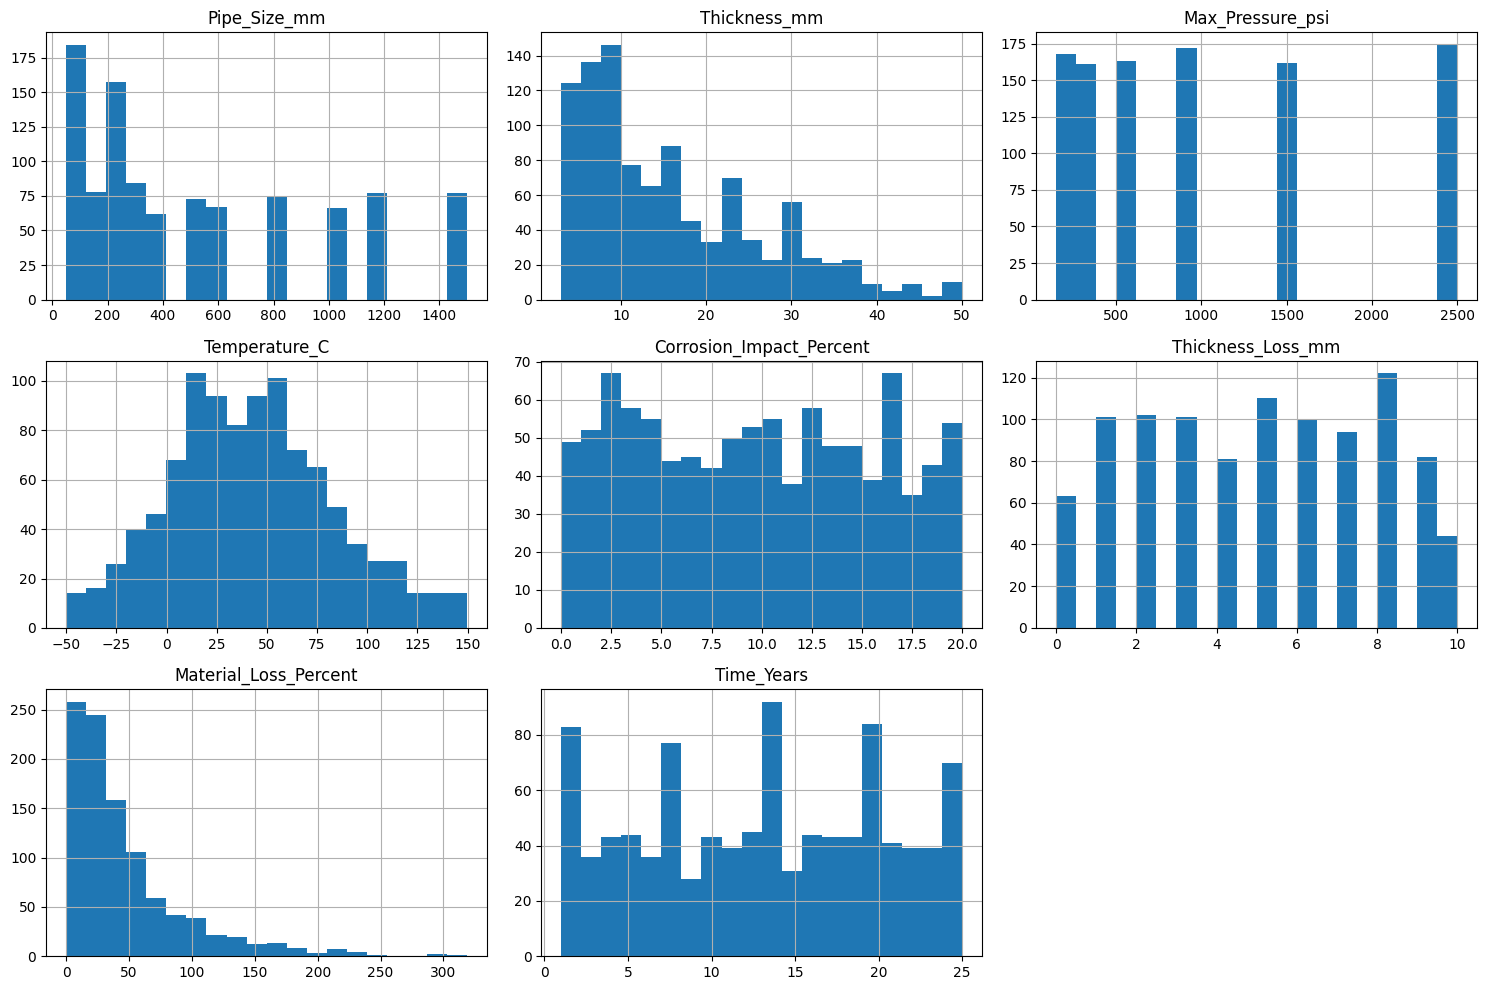

In [4]:
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Histograms
df[numeric_cols].hist(figsize=(15,10), bins=20)

plt.tight_layout()
plt.show()

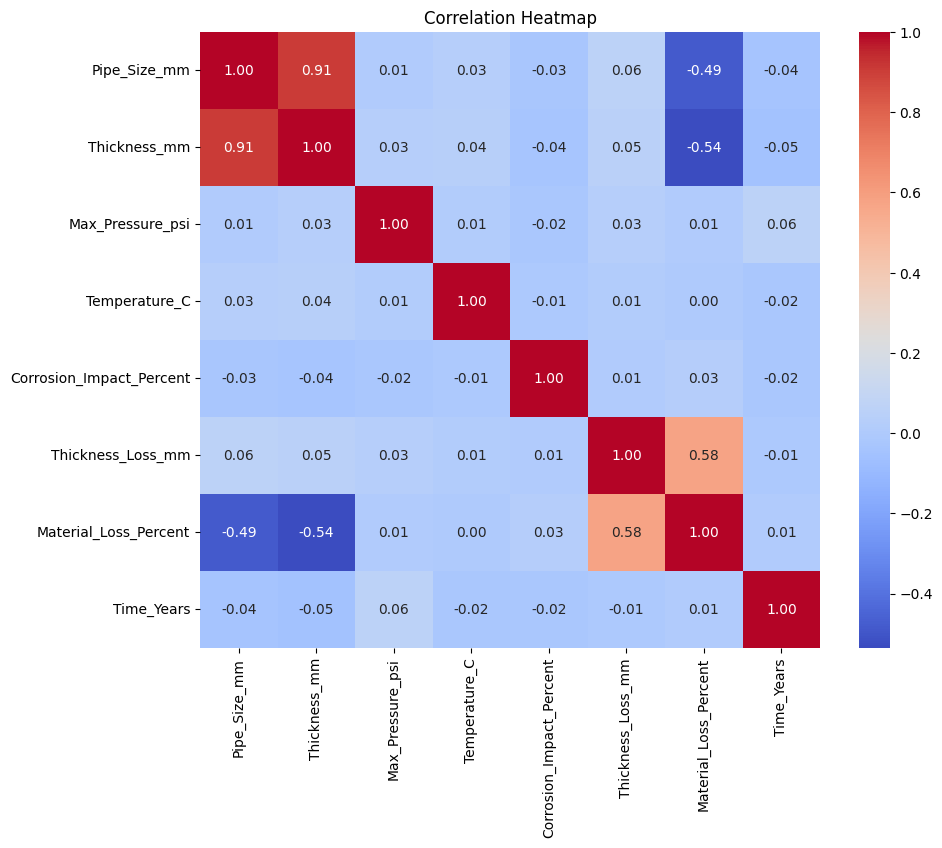

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

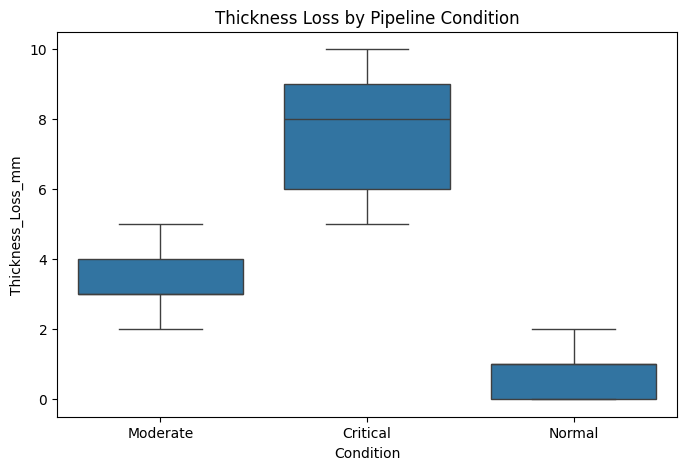

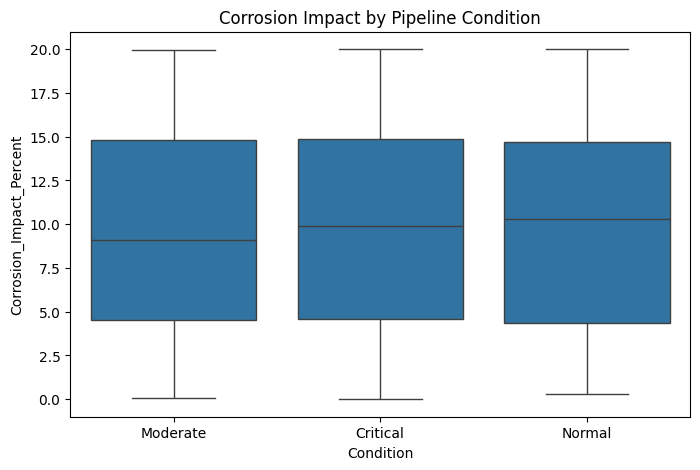

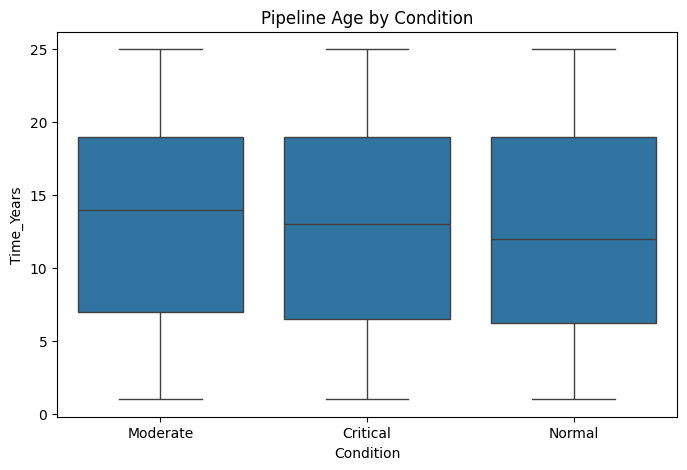

In [6]:
# Boxplots for three numeric variables against the "Condition" column
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Thickness_Loss_mm" # Boxplot for Thickness Loss by Pipeline Condition
)

plt.title("Thickness Loss by Pipeline Condition")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Corrosion_Impact_Percent" # Boxplot for Corrosion Impact by Pipeline Condition
)

plt.title("Corrosion Impact by Pipeline Condition")
plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Time_Years" # Boxplot for Pipeline Age by Pipeline Condition
)

plt.title("Pipeline Age by Condition")
plt.show()

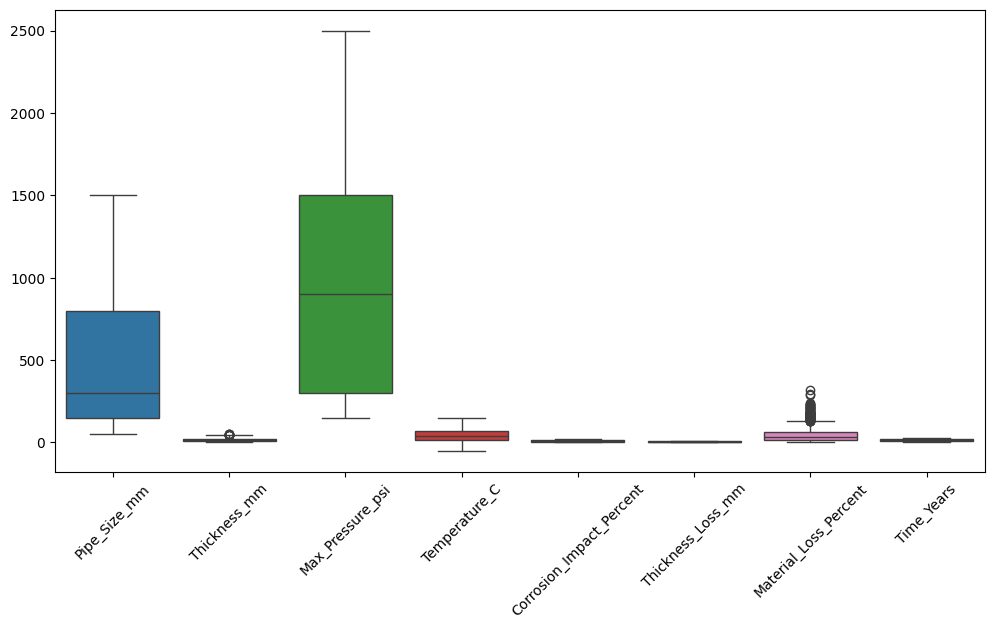

In [7]:
# Boxplots for all numeric variables
plt.figure(figsize=(12,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)

plt.show() 

In [8]:
grouped = df.groupby("Condition")[numeric_cols].mean()

print(grouped)

           Pipe_Size_mm  Thickness_mm  Max_Pressure_psi  Temperature_C  \
Condition                                                                
Critical     557.494867     16.737166       1004.414784      43.252567   
Moderate     464.882943     14.849498       1017.224080      40.078595   
Normal       521.028037     16.257009        985.046729      44.617290   

           Corrosion_Impact_Percent  Thickness_Loss_mm  Material_Loss_Percent  \
Condition                                                                       
Critical                   9.794702           7.468172              70.153018   
Moderate                   9.589097           3.531773              35.758562   
Normal                     9.854346           0.939252               8.837523   

           Time_Years  
Condition              
Critical    12.792608  
Moderate    13.478261  
Normal      12.621495  


In [9]:
df["Material_Loss_Percent"].describe()

print(df["Material_Loss_Percent"].max())

df.nlargest(10, "Material_Loss_Percent")

318.75


,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
256,50,3,Carbon Steel,ASTM A106 Grade B,300,32.6,4.60,10,318.75,15,Critical
263,50,3,Fiberglass,ASTM A333 Grade 6,1500,34.6,5.32,10,292.92,11,Critical
225,50,3,PVC,API 5L X52,2500,88.0,14.16,10,289.43,18,Critical
724,50,4,Fiberglass,ASTM A333 Grade 6,300,63.5,4.65,9,240.11,2,Critical
35,50,4,PVC,ASTM A333 Grade 6,150,63.0,16.94,10,235.31,1,Critical
926,100,4,HDPE,ASTM A106 Grade B,2500,66.9,1.39,9,231.62,20,Critical
296,100,4,HDPE,ASTM A106 Grade B,900,131.5,17.74,10,225.86,11,Critical
235,50,4,Carbon Steel,ASTM A333 Grade 6,600,-13.4,18.10,8,224.66,5,Critical
746,50,3,PVC,ASTM A333 Grade 6,900,75.5,19.11,7,220.94,4,Critical
922,100,4,PVC,API 5L X52,1500,16.9,11.22,10,219.08,10,Critical


In [10]:
    # Records where thickness loss exceeds wall thickness
invalid_records = df[df["Thickness_Loss_mm"] > df["Thickness_mm"]]

print(f"Number of physically inconsistent records: {len(invalid_records)}")

# Percentage of the dataset
print(f"Percentage: {len(invalid_records)/len(df)*100:.2f}%")

# Preview a few examples
invalid_records.head()

Number of physically inconsistent records: 101
Percentage: 10.10%


,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
13,150,5,HDPE,ASTM A333 Grade 6,300,43.6,16.02,6,117.92,13,Critical
15,100,6,Fiberglass,API 5L X65,1500,60.1,18.79,7,116.83,21,Critical
21,100,6,Carbon Steel,ASTM A106 Grade B,1500,45.3,12.17,8,133.63,10,Critical
34,50,5,PVC,ASTM A333 Grade 6,600,51.7,14.89,9,195.82,1,Critical
35,50,4,PVC,ASTM A333 Grade 6,150,63.0,16.94,10,235.31,1,Critical


# Engineering Data Validation

As part of quality assurance, engineering constraints were verified.

A notable observation was that approximately **10.1%** of records contained Thickness Loss values greater than the original wall Thickness.

These values are physically unrealistic and suggest that the dataset is synthetic or contains measurement inconsistencies.

# Data Preprocessing

The preprocessing pipeline included:

- One-Hot Encoding
- Label Encoding
- Feature Scaling
- Stratified Train/Test Split

These steps prepare the dataset for Machine Learning while minimizing bias and preserving class distribution.

In [11]:
import pandas as pd

# Create a working copy
df_ml = df.copy()

# Features
X = df_ml.drop("Condition", axis=1)

# Target
y = df_ml["Condition"]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(label_encoder.classes_)

X = pd.get_dummies(
    X,
    columns=["Material", "Grade"],
    drop_first=True
)

print(X.head())

print("Number of features:", X.shape[1])

print(X.columns)


['Critical' 'Moderate' 'Normal']
   Pipe_Size_mm  Thickness_mm  Max_Pressure_psi  Temperature_C  \
0           800            15               300           84.9   
1           800            22               150           14.1   
2           400            12              2500            0.6   
3          1500            39              1500           52.7   
4          1500            24              1500           11.7   

   Corrosion_Impact_Percent  Thickness_Loss_mm  Material_Loss_Percent  \
0                     16.04                  5                  31.72   
1                      7.38                  7                  33.27   
2                      2.12                  6                  52.45   
3                      5.58                  6                  16.01   
4                     12.29                  9                  35.28   

   Time_Years  Material_Fiberglass  Material_HDPE  Material_PVC  \
0           2                False          False         False 

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

numerical_cols = [
    "Pipe_Size_mm",
    "Thickness_mm",
    "Max_Pressure_psi",
    "Temperature_C",
    "Corrosion_Impact_Percent",
    "Thickness_Loss_mm",
    "Material_Loss_Percent",
    "Time_Years"
]
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_scaled[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)
print("Original feature matrix:", X.shape)

print("Training:", X_train.shape)

print("Testing:", X_test.shape)

print("\nScaled training sample:")

X_train_scaled.head()

Training set: (800, 16)
Testing set: (200, 16)
Original feature matrix: (1000, 16)
Training: (800, 16)
Testing: (200, 16)

Scaled training sample:


,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Material_Fiberglass,Material_HDPE,Material_PVC,Material_Stainless Steel,Grade_API 5L X52,Grade_API 5L X65,Grade_ASTM A106 Grade B,Grade_ASTM A333 Grade 6
502,-0.838278,-1.049432,-1.064191,1.163869,-0.706440,-1.322499,-0.454833,1.554037,False,False,False,True,False,True,False,False
465,0.182802,-0.478313,0.616848,1.734587,1.372815,-1.322499,-0.848536,0.284428,False,True,False,False,False,False,False,True
694,1.544241,0.568740,-1.064191,2.084691,-1.282101,1.069618,-0.259489,-0.138775,False,False,True,False,False,False,True,False
401,2.224961,2.186912,-0.877409,-1.354004,-0.543192,-0.639037,-0.833245,0.848699,False,True,False,False,False,False,False,True
677,2.224961,1.901352,-0.877409,0.247843,0.881355,-0.639037,-0.807400,-1.267317,False,False,True,False,False,False,False,True


In [13]:
# Convert boolean columns to integers
bool_cols = X_train_scaled.select_dtypes(include="bool").columns

X_train_scaled[bool_cols] = X_train_scaled[bool_cols].astype(int)
X_test_scaled[bool_cols] = X_test_scaled[bool_cols].astype(int)

print(X_train_scaled.dtypes)

Pipe_Size_mm                float64
Thickness_mm                float64
Max_Pressure_psi            float64
Temperature_C               float64
Corrosion_Impact_Percent    float64
Thickness_Loss_mm           float64
Material_Loss_Percent       float64
Time_Years                  float64
Material_Fiberglass           int64
Material_HDPE                 int64
Material_PVC                  int64
Material_Stainless Steel      int64
Grade_API 5L X52              int64
Grade_API 5L X65              int64
Grade_ASTM A106 Grade B       int64
Grade_ASTM A333 Grade 6       int64
dtype: object


## Training Random Forest Model
### Random Forest Model

Random Forest was selected as the baseline model due to its robustness, interpretability and ability to handle nonlinear relationships.

Performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [15]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)
# Evaluate the model
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)) 

Accuracy: 0.925

Classification Report:

              precision    recall  f1-score   support

    Critical       0.97      0.93      0.95        97
    Moderate       0.84      0.93      0.88        60
      Normal       0.97      0.91      0.94        43

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200



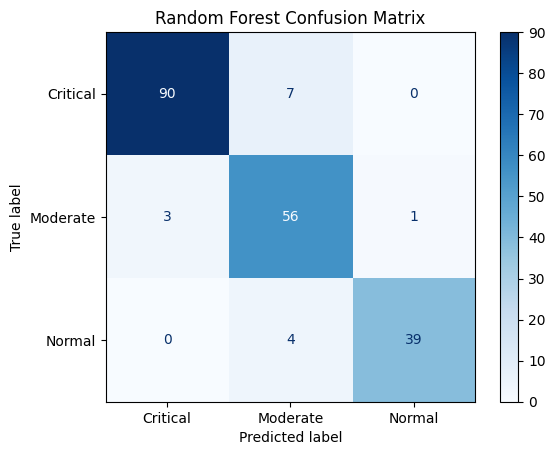

In [16]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_scaled,
    y_test,
    display_labels=label_encoder.classes_,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

                     Feature  Importance
5          Thickness_Loss_mm    0.529070
6      Material_Loss_Percent    0.234840
1               Thickness_mm    0.051131
0               Pipe_Size_mm    0.035002
3              Temperature_C    0.034459
4   Corrosion_Impact_Percent    0.032238
7                 Time_Years    0.030608
2           Max_Pressure_psi    0.016026
8        Material_Fiberglass    0.006177
10              Material_PVC    0.005287


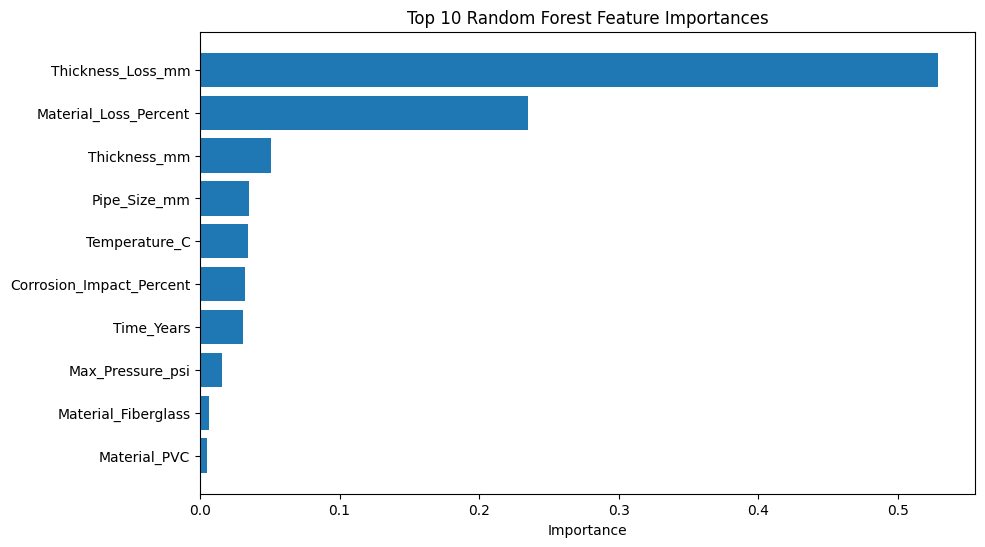

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10][::-1],
    feature_importance["Importance"][:10][::-1]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

## Installing XGBoost

In [18]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 1.6 MB/s eta 0:00:43
    --------------------------------------- 1.3/69.5 MB 1.9 MB/s eta 0:00:36
   - -------------------------------------- 1.8/69.5 MB 2.1 MB/s eta 0:00:32
   - -------------------------------------- 2.1/69.5 MB 2.2 MB/s eta 0:00:31
   - -------------------------------------- 2.4/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.4/69.5 MB 2.1 MB/s eta 0:00:33
   - -------------------------------------- 2.6/69.5 MB 1.5 MB/s eta 0:00:44
   - ----------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Training XGBoost
### XGBoost Model

XGBoost was trained and compared against Random Forest.

The comparison helps determine whether increased model complexity produces meaningful improvements.

In [19]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


Accuracy: 0.905

Classification Report:

              precision    recall  f1-score   support

    Critical       0.94      0.93      0.93        97
    Moderate       0.84      0.85      0.84        60
      Normal       0.93      0.93      0.93        43

    accuracy                           0.91       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.91      0.91      0.91       200



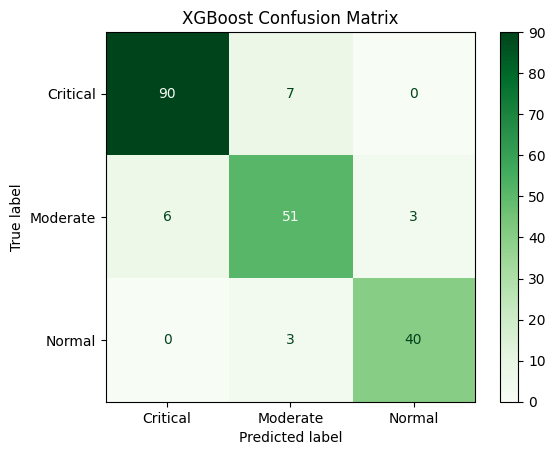

In [22]:
y_pred_xgb = xgb_model.predict(X_test_scaled)   

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test_scaled,
    y_test,
    display_labels=label_encoder.classes_,
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

# Model Explainability using SHAP

SHAP values explain how each feature contributes to model predictions.

This provides transparency and helps verify that model decisions align with engineering expectations.

In [23]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/43.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/43.0 MB 2.2 MB/s eta 0:00:20
    --------------------------------------- 0.8/43.0 MB 1.7 MB/s eta 0:00:25
    --------------------------------------- 1.0/43.0 MB 2.3 MB/s eta 0:00:19
   - -------------------------------------- 1.6/43.0 MB 1.8 MB/s eta 0:00:23
   - -------------------------------------- 2.1/43.0 MB 2.0 MB/s eta 0:00:21
   -- ------------------------------------- 2.6/43.0 MB 2.0 MB/s eta 0:00:20
   -- ------------------------------------- 2.9/43.0 MB 2.1 MB/s eta 0:00:19
   -- ------------------------------------- 3.1/43.0 MB 2.0 MB/s eta 0:00:20
   -- ------------------------------------- 3.1/43.0 MB 2.0 MB/s eta 0:00:20
   --- ------------------------------------ 3.4/43.0 MB 1.6 MB/s eta 0:00:25
   --- ------------------------------------ 3.4/43.0 MB 1.6 MB/s eta 0:00:25
   --


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\HomePC\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


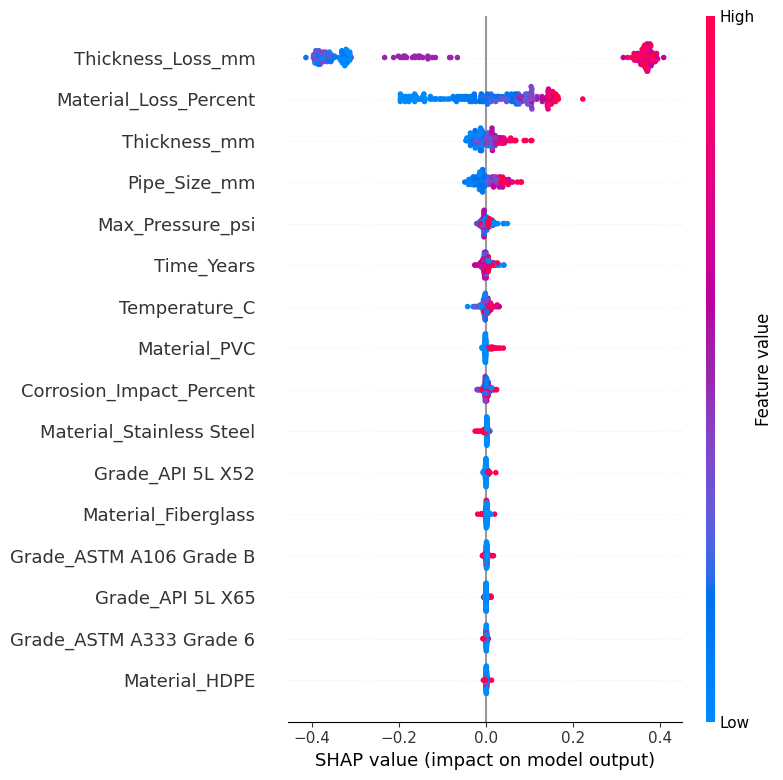

In [24]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_scaled)

# SHAP summary plot for the Critical class
shap.summary_plot(
    shap_values[:, :, 0],
    X_test_scaled,
    feature_names=X_train.columns
)

# Conclusion

Random Forest achieved the best performance with an accuracy of **92.5%**.

The model identified Thickness Loss and Material Loss as the strongest indicators of pipeline deterioration.

This project demonstrates how Machine Learning can support predictive maintenance and pipeline integrity management.